## 11. Optional: Hyperparameter Tuning

Tuning tries multiple parameter combinations with `TimeSeriesSplit`. This can take a long time. Use it only after the simple training run works.


Info: The following columns are in the dataset but not recorded in the feature engineering lists: {'total_flights_in_hour_ARR', 'flights_departing_in_hour_ARR', 'Unnamed: 0', 'total_flights_in_hour_DEP', 'flights_arriving_in_hour_ARR', 'rhum_ARR', 'rhum', 'flights_arriving_in_hour_DEP', 'flights_departing_in_hour_DEP', 'information_hour_local', 'hd_ground_crew_carrier_3d'}
Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\miniconda3\envs\imgP\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:47:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-macro: 0.3618
F1-macro: 0.3830


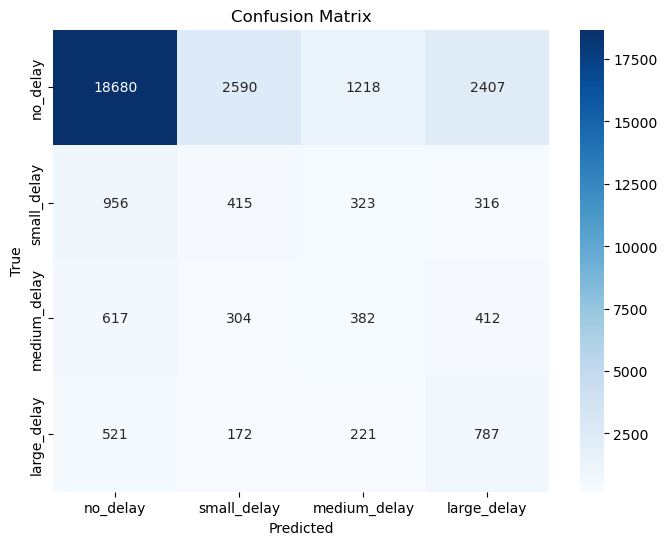

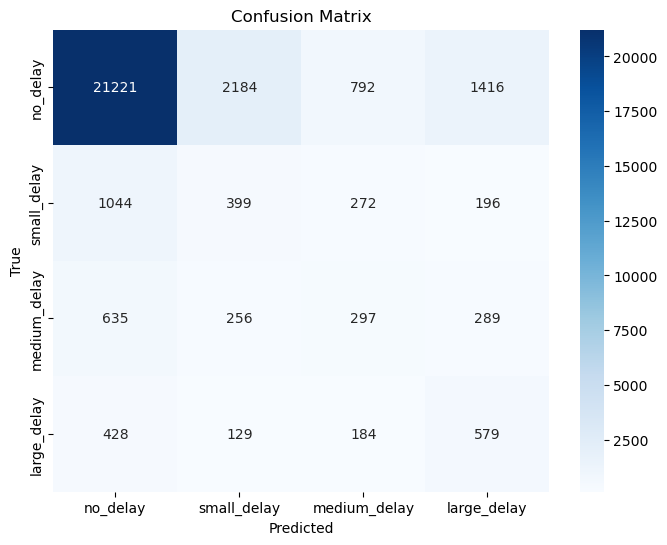

In [ ]:
# Uncomment this cell when you are ready for a slower tuning run.
tuned_config = TrainingConfig(
    data_root=DATA_ROOT,
    input_path=INPUT_PATH,
    output_dir='outputs/training_notebook_tuned',
    model_name=MODEL_NAME,
    delay_column=DELAY_COLUMN,
    target_column=TARGET_COLUMN,
    time_column=TIME_COLUMN,
    sample_frac=SAMPLE_FRAC,
    tune=True,
    n_iter=3,
    cv_splits=3,
)
tuned_metrics,tuned_val_predictions,tuned_test_predictions = run_training(tuned_config)
pd.Series(tuned_metrics, name='tuned_pipeline_metrics')
# plot the confusion matrix for the tuned pipeline model
plotConfusionMatrix(predictions=tuned_val_predictions, y_true=y_val)
plotConfusionMatrix(predictions=tuned_test_predictions, y_true=y_test)